## 25.09.21: Line and Conic Detection

In [1]:
import sys, os, json
sys.path.append(os.path.abspath('..'))

from tqdm import tqdm
from itertools import pairwise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import cv2
from ultralytics import YOLO

from scripts.classes.pitch import Pitch, PitchKeypointMapping, HomographySolver
from scripts.datasets.calibration import CalibrationDataset, CalibrationLabelsMapping
from scripts.datasets.field_masking import MaskingCalibrationDataset
from scripts.datasets.field_pitch import PitchKeypointCalibrationDataset
from SoccerNet.Downloader import SoccerNetDownloader

print(f'Torch CUDA availability: {torch.cuda.is_available()}')
print(f'Torch MPS availability: {torch.mps.is_available()}')

WIDTH, HEIGHT = 320, 180

Torch CUDA availability: False
Torch MPS availability: True


/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
calibration_train_dataset = CalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
calibration_test_dataset = CalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
calibration_valid_dataset = CalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(calibration_train_dataset)}')
print(f'Number of test samples: {len(calibration_test_dataset)}')
print(f'Number of valid samples: {len(calibration_valid_dataset)}')

limit: 128
limit: 128
limit: 128
Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


In [3]:
masking_calibration_train_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_test_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_valid_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(masking_calibration_train_dataset)}')
print(f'Number of test samples: {len(masking_calibration_test_dataset)}')
print(f'Number of valid samples: {len(masking_calibration_valid_dataset)}')

limit: 128
limit: 128
limit: 128
Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


In [4]:
pitch_keypoint_calibration_train_dataset = PitchKeypointCalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
pitch_keypoint_calibration_test_dataset = PitchKeypointCalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
pitch_keypoint_calibration_valid_dataset = PitchKeypointCalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(pitch_keypoint_calibration_train_dataset)}')
print(f'Number of test samples: {len(pitch_keypoint_calibration_test_dataset)}')
print(f'Number of valid samples: {len(pitch_keypoint_calibration_valid_dataset)}')

limit: None
limit: None
limit: None
Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


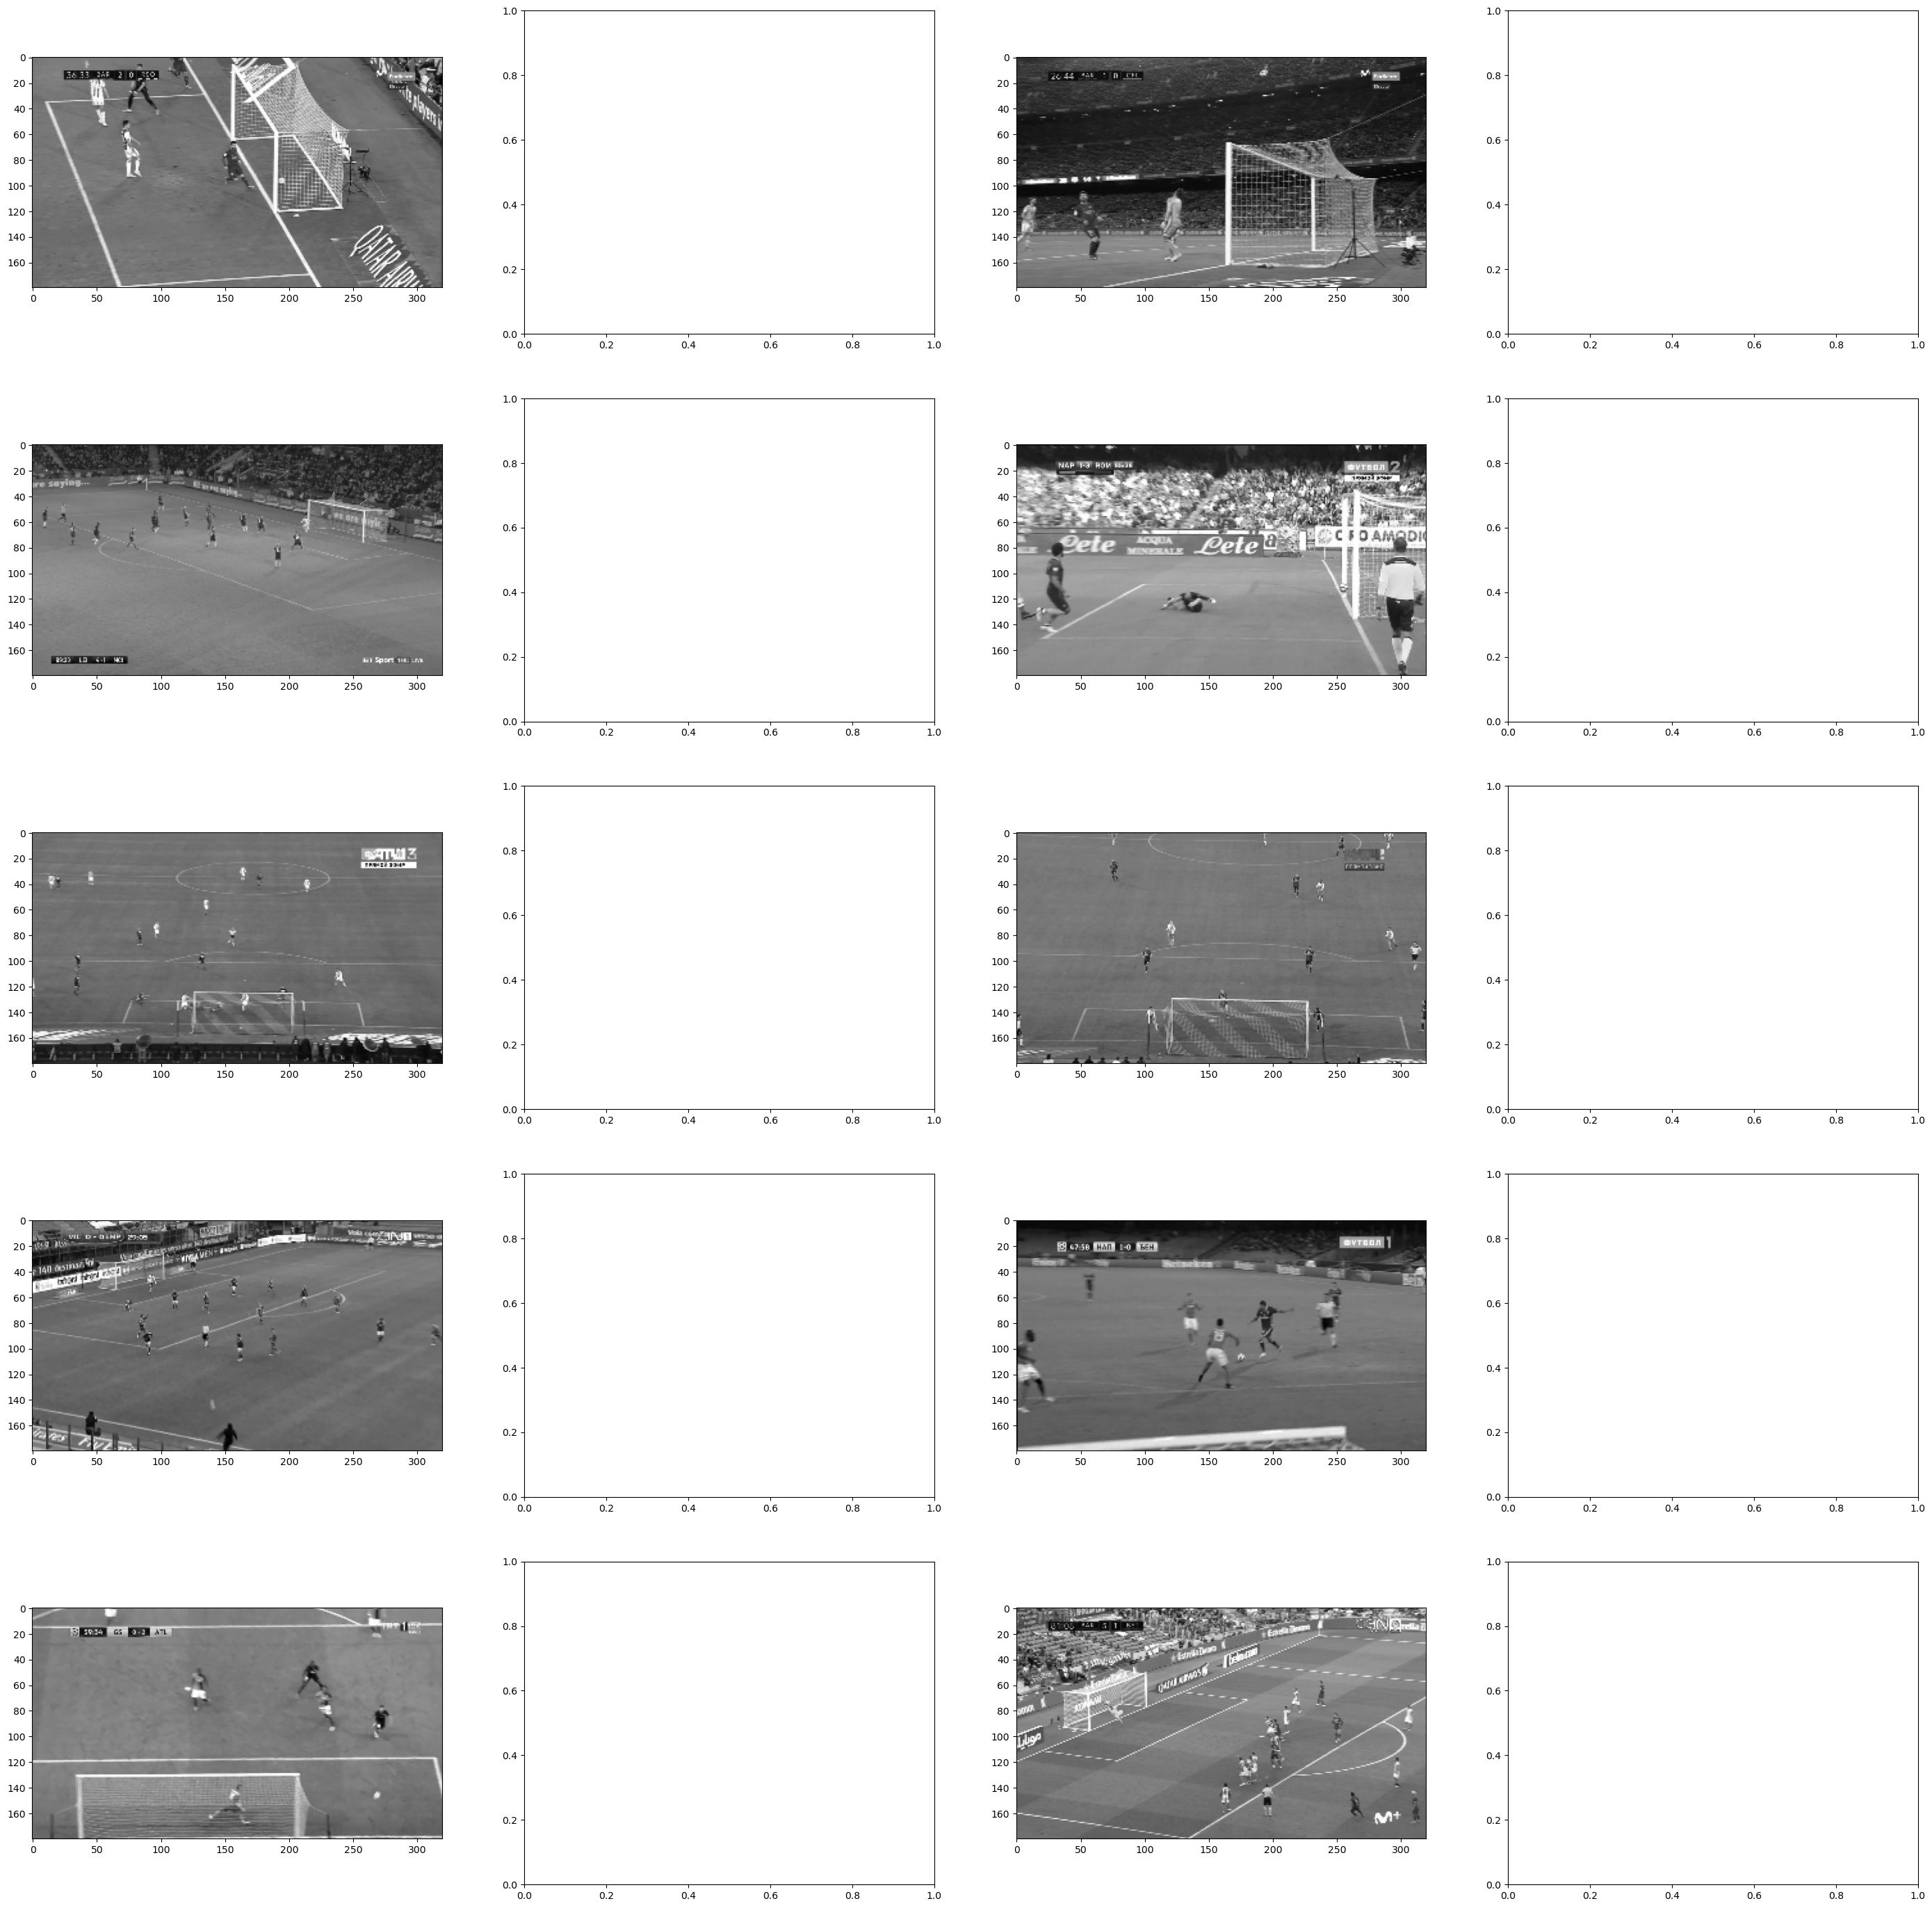

In [5]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(35, 35))

for idx in range(0, len(axes.flat), 2):
    img, labels = calibration_train_dataset[idx]
    axes.flat[idx].imshow(img, cmap='gray')
    # axes.flat[idx + 1].imshow(mask, cmap='gray')

plt.show()

## UNet

https://arxiv.org/abs/2504.14131

In [6]:
DEVICE = torch.device('cpu')
torch.mps.empty_cache()

torch.hub.load('sm00thix/unet', 'unet', pretrained=False, in_channels=1, out_channels=1, pad=True, bilinear=True, normalization='bn')
unet_model = torch.load('../weights/experimental/251006-unet-model.pt').to(DEVICE)
unet_model.eval()

print(f'UNet model device: {next(unet_model.parameters()).device}')

Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main
/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_79538/262586736.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this ex

UNet model device: cpu


In [7]:
torch.mps.empty_cache()

batch_size = 4
valid_dataloader = DataLoader(pitch_keypoint_calibration_valid_dataset, batch_size=batch_size, shuffle=False)
img, mask = next(iter(valid_dataloader))
img = img.float().unsqueeze(1).to(DEVICE)
mask = mask.float().unsqueeze(1).to(DEVICE)

unet_model.eval()
out_mask = unet_model(img)
print(f'img.shape = {img.shape}, out_mask.shape = {out_mask.shape}, mask.shape = {mask.shape}')

img = img.to('cpu')
mask = img.to('cpu')

img.shape = torch.Size([4, 1, 180, 320]), out_mask.shape = torch.Size([4, 1, 180, 320]), mask.shape = torch.Size([4, 1, 27, 3])


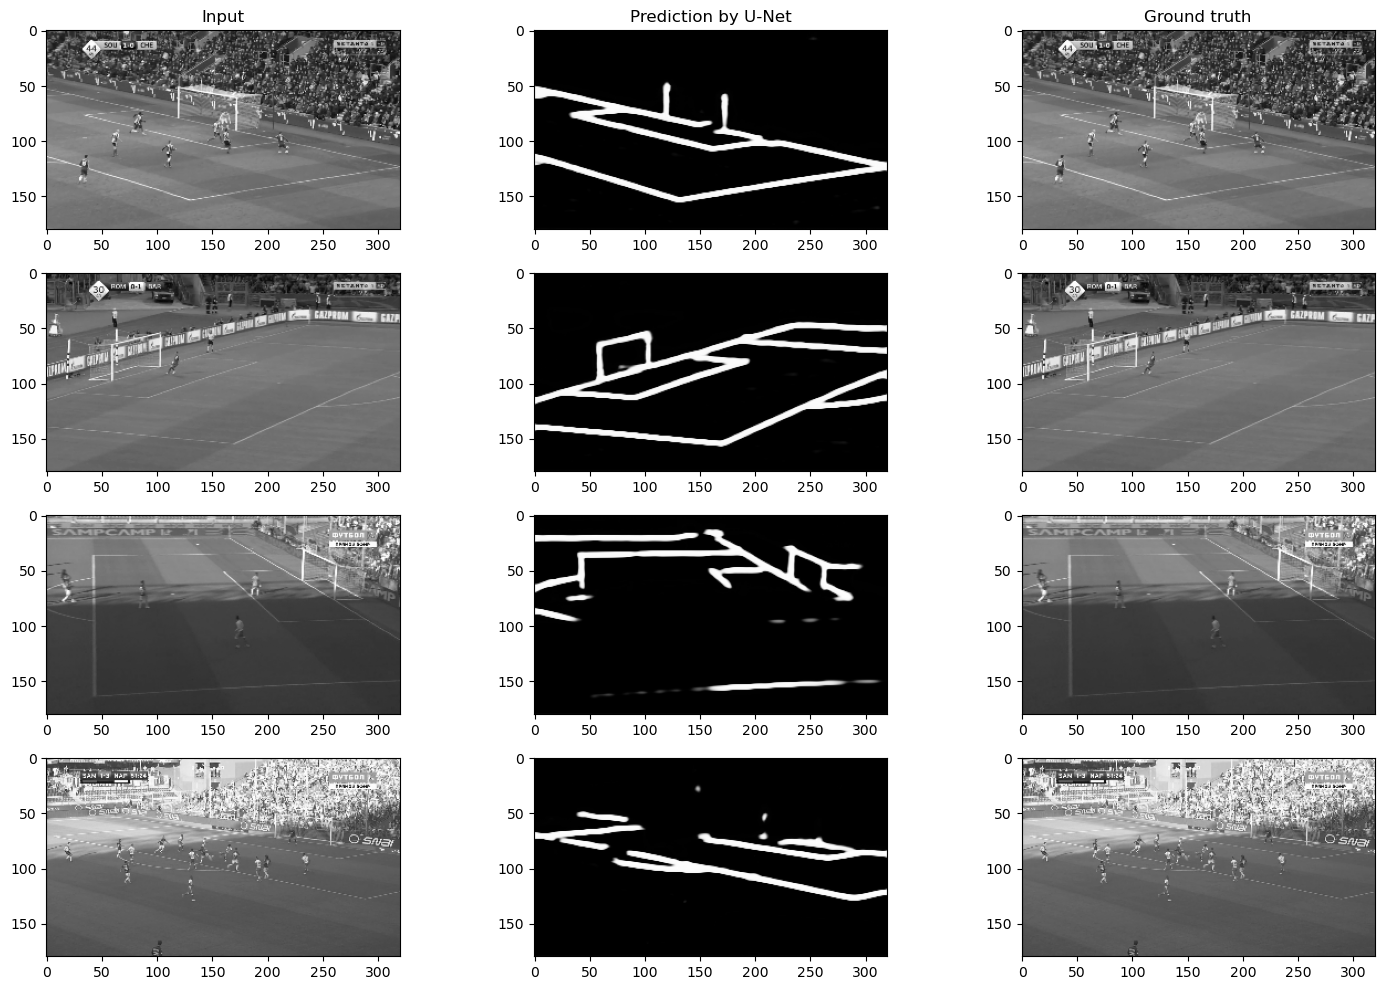

In [8]:
fig, axes = plt.subplots(nrows=batch_size, ncols=3, figsize=(15, 10))
def img_convert(img):
    return img.permute((1, 2, 0)).cpu().detach().numpy()

for idx in range(batch_size):
    axes[idx, 0].imshow(img_convert(img[idx]), cmap='gray')
    axes[idx, 1].imshow(img_convert(out_mask[idx]), cmap='gray')
    axes[idx, 2].imshow(img_convert(mask[idx]), cmap='gray')

axes[0, 0].set_title('Input')
axes[0, 1].set_title('Prediction by U-Net')
axes[0, 2].set_title('Ground truth')

fig.tight_layout()
plt.show()

In [9]:
len(pitch_keypoint_calibration_train_dataset)

128

## Homography Estimation Net

Paper: https://arxiv.org/pdf/1606.03798

[[      0.161       -0.03      -0.262]
 [     -0.034       0.114       0.939]
 [         -0          -0       0.091]]


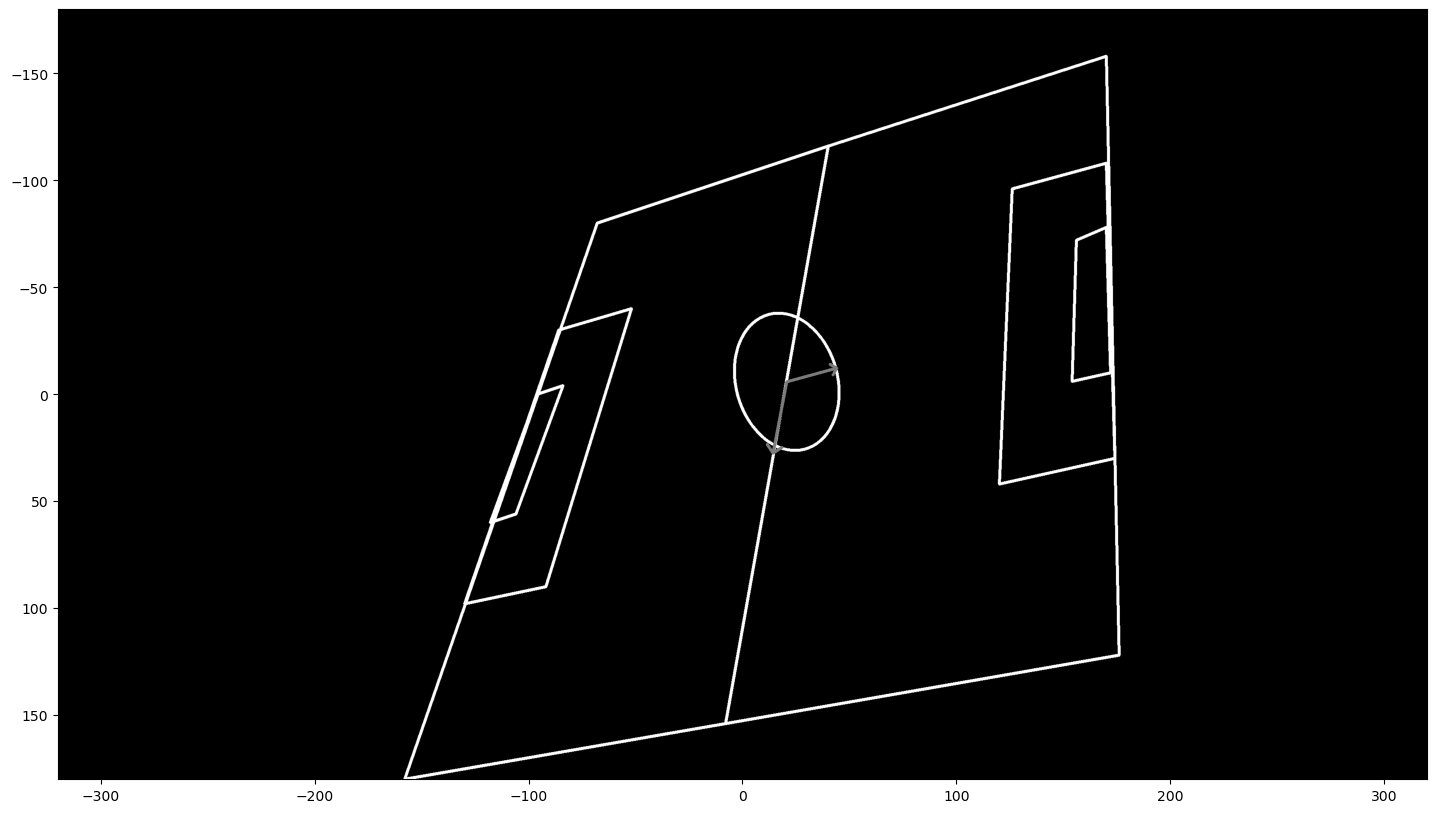

In [125]:
A = torch.Tensor([[-37.5, -55.0, 1], [37.5, -55.0, 1], [-37.5, 55.0, 1], [37.5, 55.0, 1], [32.5, 52.0, 1]])
B = torch.Tensor([[-40.0, -35.0, 1], [90.0, -80.0, 1], [-80.0, 85.0, 1], [60, 90.0, 1], [50, 80.0, 1]])
H = HomographySolver()(A.unsqueeze(0), B.unsqueeze(0))[0]

pitch = Pitch().apply_homography(H)
print(torch.round(H, decimals=3).numpy())

fig, ax = plt.subplots(figsize=(20, 10))
pitch.plot(ax, scale=10)
plt.show()

In [107]:
class HomographyConvFeatureLearner(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv 1: 180x320x1 -> 90x160x32
        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Conv 2: 90x160x32 -> 45x80x64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Conv 3: 45x80x64 -> 22x40x128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Conv 4: 22x40x128 -> 11x20x256
        self.conv4 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        # Conv 5: 11x20x256 -> 11x20x256 (Preserve size, increase feature complexity)
        self.conv5 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(256)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        return x 

class HomographyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_learner_1 = HomographyConvFeatureLearner()
        self.conv_learner_2 = HomographyConvFeatureLearner()

        # Flattened size: 11 * 20 * 256 = 56320
        self.fc_half_input_size = 11 * 20 * 256
        
        # Dense 1: 56320 * 2 -> 220
        self.fc1 = nn.Linear(self.fc_half_input_size * 2, 220)
        
        # Dense 2: 220 -> 9 (Final Output)
        self.fc2 = nn.Linear(220, 9)

    def forward(self, x, y):
        x = self.conv_learner_1(x)
        y = self.conv_learner_2(y)

        x = x.view(-1, self.fc_half_input_size)     # Flatten layer: 11 * 20 * 256 = 56320 elements
        y = y.view(-1, self.fc_half_input_size)     # Flatten layer: 11 * 20 * 256 = 56320 elements

        # print(f'{x.shape} + {y.shape} = ', end='')
        x = torch.concatenate([x, y], dim=1)
        # print(x.shape)

        x = F.relu(self.fc1(x))                     # Dense layers
        x = self.fc2(x)                             # Final output layer (12 elements for the homography parameters)
        x = F.normalize(x, p=2, dim=1)              # Normalisation: ensure h_11^2 + ... + h_33^2 = 1 ==> Removing one DoF
        # ones = x.new_ones(x.size(0), 1)
        # x = torch.cat([x, ones], dim=1)
        x = x.view(-1, 3, 3)                        # Reshape to matrix -1 x 3 x 3

        # x = self.fc2(x)                             # Final output layer (12 elements for the homography parameters)
        # x = x.view(-1, 4, 3)                        # Reshape to matrix 4 x 3
        # x[:, :, 0] *= HEIGHT
        # x[:, :, 1] *= WIDTH
        return x

In [116]:
class HomographyKeypointLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.homography_solver = HomographySolver()
        self.original_pitch = Pitch(height=180, width=320)

    def forward(self, homography, target_all_keypoints_):
        n_batch = homography.shape[0]
        pitch_all_keypoints = self.original_pitch.batched_keypoints(n_batch) @ homography.transpose(2, 1)

        pitch_all_keypoints = pitch_all_keypoints[:, :, 0:2] / pitch_all_keypoints[:, :, 2:3]
        target_all_keypoints = target_all_keypoints_[:, :, 0:2] / target_all_keypoints_[:, :, 2:3]

        # n_batch x n_points x 2
        # print(pitch_all_keypoints - target_all_keypoints)
        distances = torch.linalg.vector_norm(pitch_all_keypoints - target_all_keypoints, ord=2, dim=2)
        return distances.mean(dim=1).sum(dim=0)

In [ ]:
# https://medium.com/@weidagang/learning-pytorch-the-basic-program-structure-ed5723118b67

torch.mps.empty_cache()
DEVICE = torch.device('mps')

n_epochs = 16    # number of epochs to run
batch_size = 16   # size of each batch

train_dataloader = DataLoader(pitch_keypoint_calibration_train_dataset, batch_size=batch_size, shuffle=False)
valid_dataloader = DataLoader(pitch_keypoint_calibration_valid_dataset, batch_size=batch_size, shuffle=False)

unet_model = torch.load('../weights/experimental/251006-unet-model.pt').to(DEVICE)
unet_model.eval()

homography_model = HomographyNet().to(DEVICE)
homography_loss_fn = HomographyKeypointLoss().to(DEVICE)  # binary cross entropy
optimiser = optim.Adam(homography_model.parameters(), lr=0.0002)

train_losses, test_losses = [], []

print(next(homography_loss_fn.original_pitch.parameters()).device)

/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_79538/3683631062.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_model = torch.load('../weights/experime

mps:0


mps:0
torch.Size([4, 1, 180, 320])


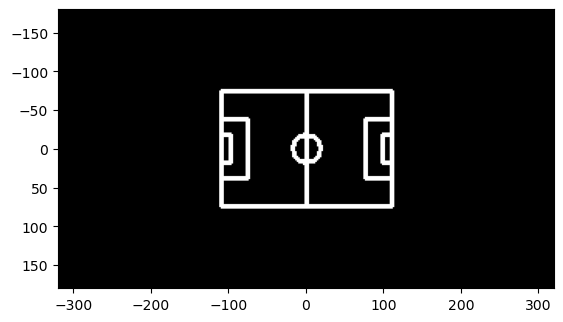

In [118]:
fig, ax = plt.subplots()
original_pitch_mask = Pitch(height=180, width=320).plot(ax=ax, scale=1, thickness=2, extra_space_scale=1, has_axes=False)
original_pitch_mask = torch.Tensor([original_pitch_mask] * batch_size).unsqueeze(1).to(DEVICE)
ax.plot()

print(original_pitch_mask.device)
print(original_pitch_mask.shape)

32it [00:44,  1.41s/it]



Epoch: 1, Train Loss: 13592.3505 



0it [00:00, ?it/s]/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_79538/3400821353.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
2it [00:00,  3.68it/s]

tensor([[1.2851, 2.3860, 1.0000],
        [1.6062, 1.7941, 1.0000],
        [1.2321, 2.2471, 1.0000],
        [1.6532, 1.8658, 1.0000]])


32it [00:08,  3.83it/s]


...


Epoch: 16, Train Loss: 13592.4478 



1it [00:00,  2.96it/s]

tensor([[1.5432, 2.9963, 1.0000],
        [1.4100, 1.1956, 1.0000],
        [1.4935, 2.8755, 1.0000],
        [1.4264, 1.2140, 1.0000]])


32it [00:08,  3.87it/s]



Epoch: 16, Test Loss: 12320.3120



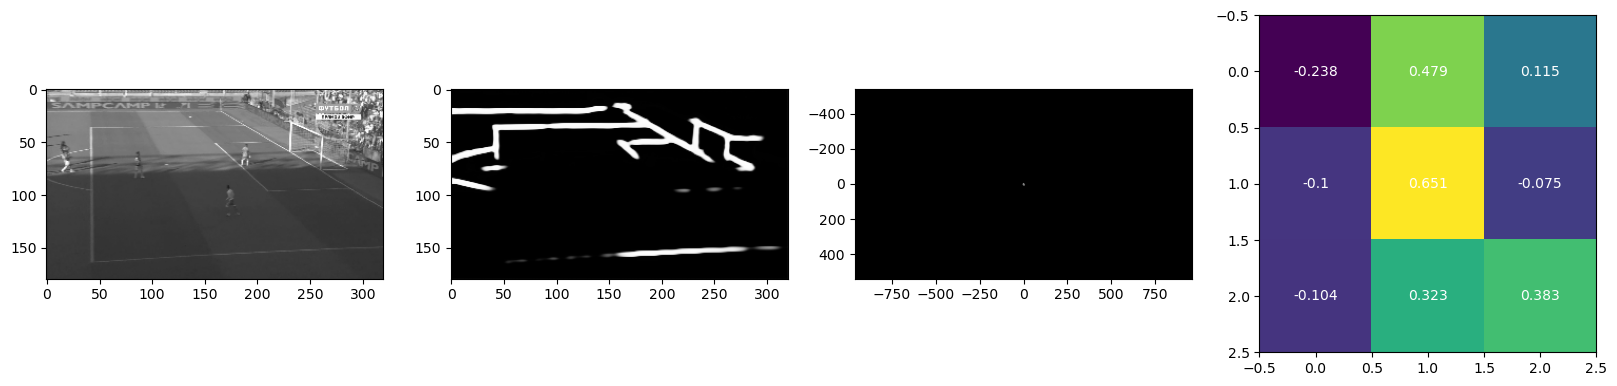

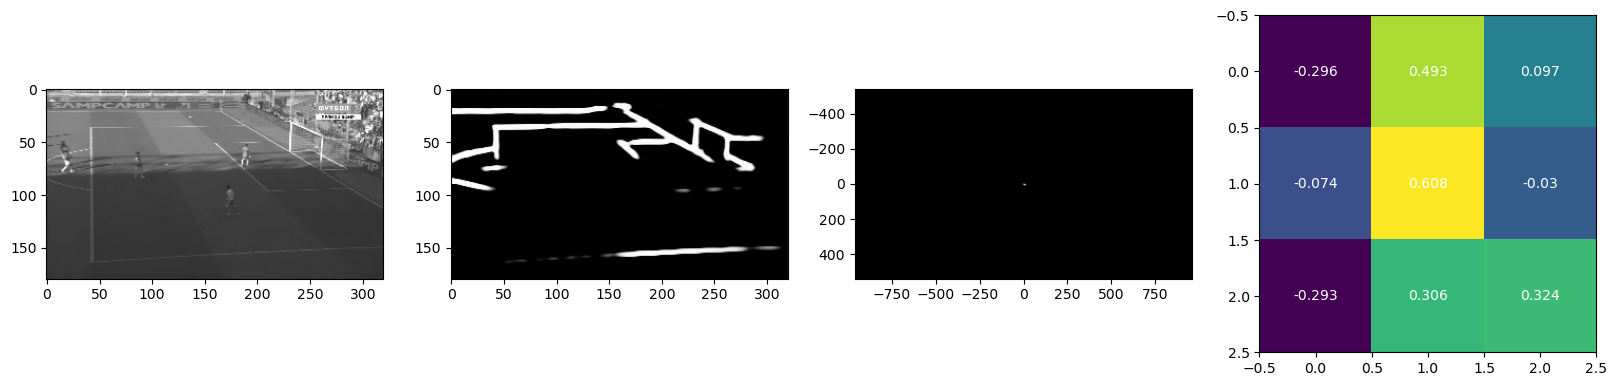

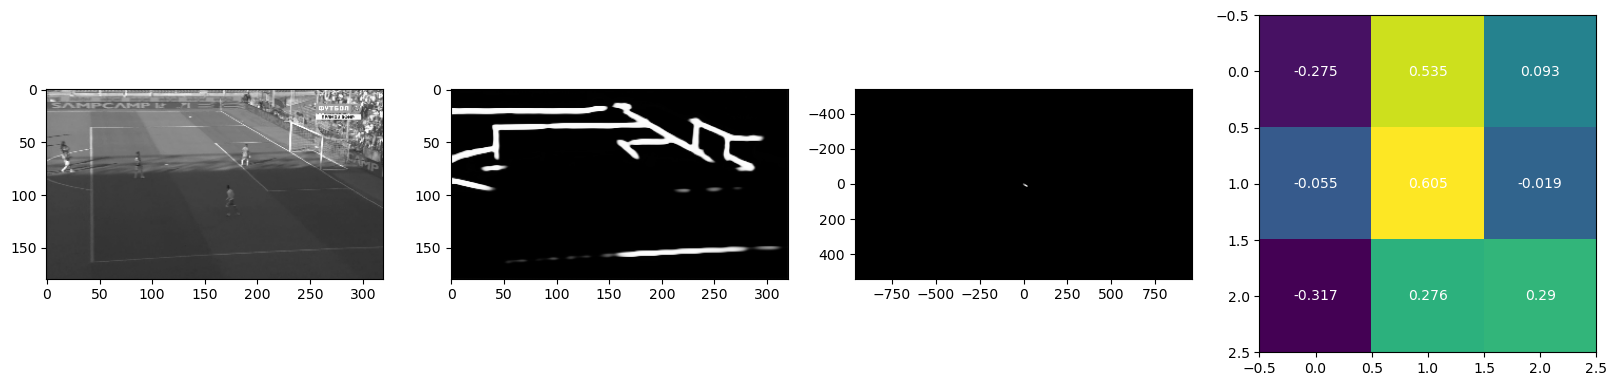

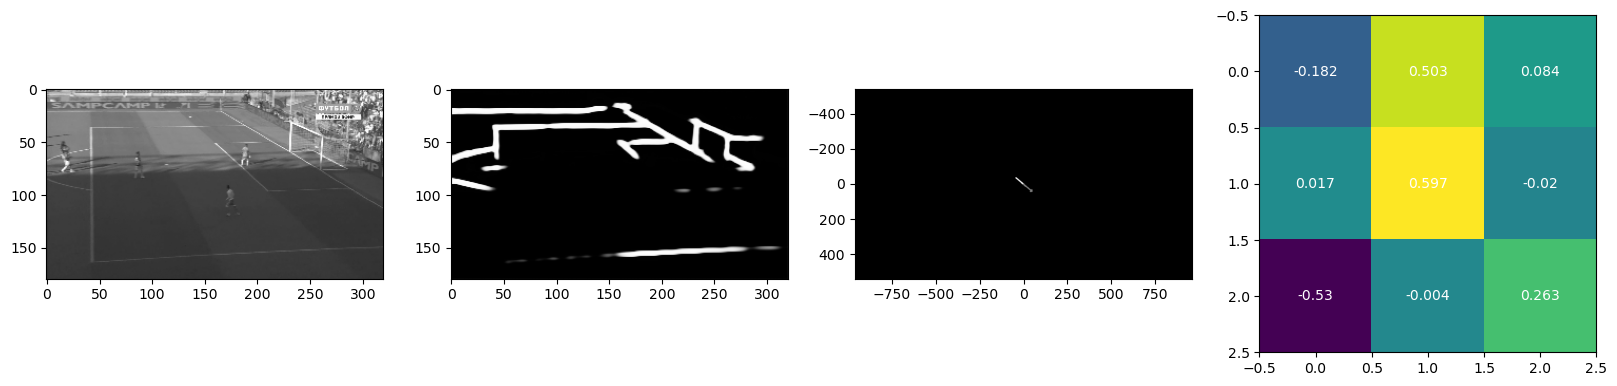

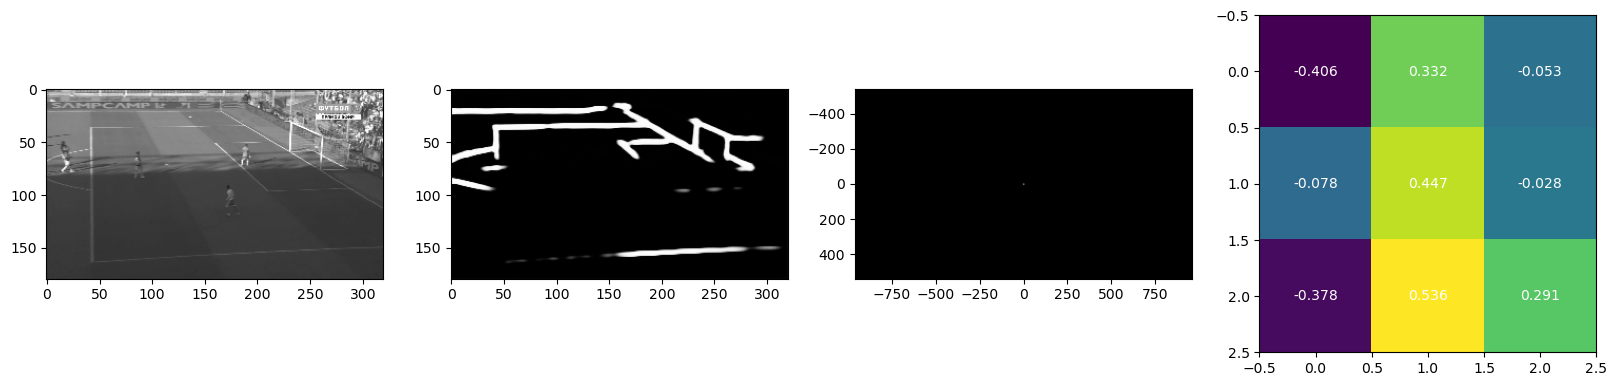

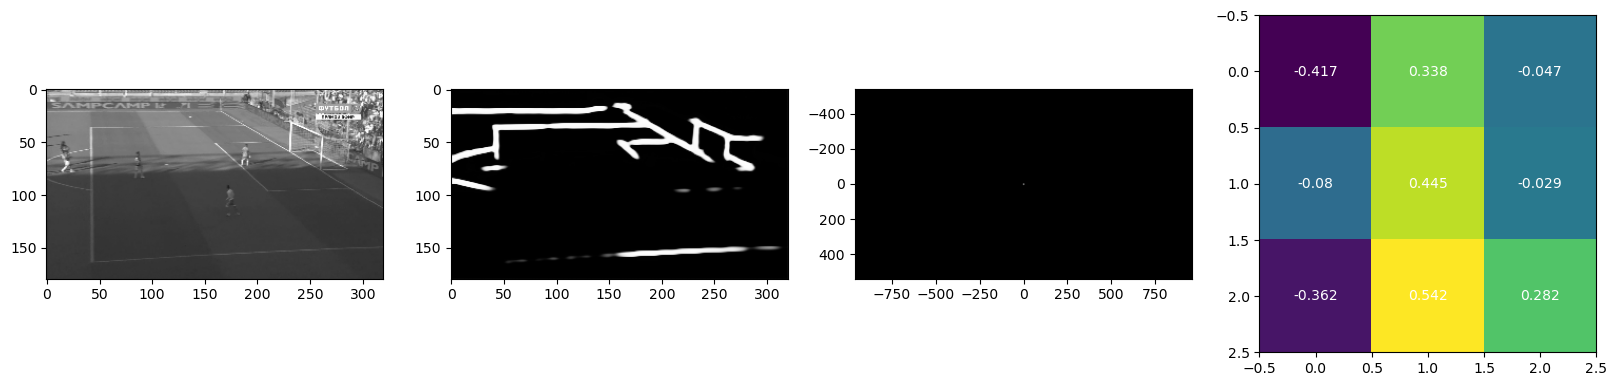

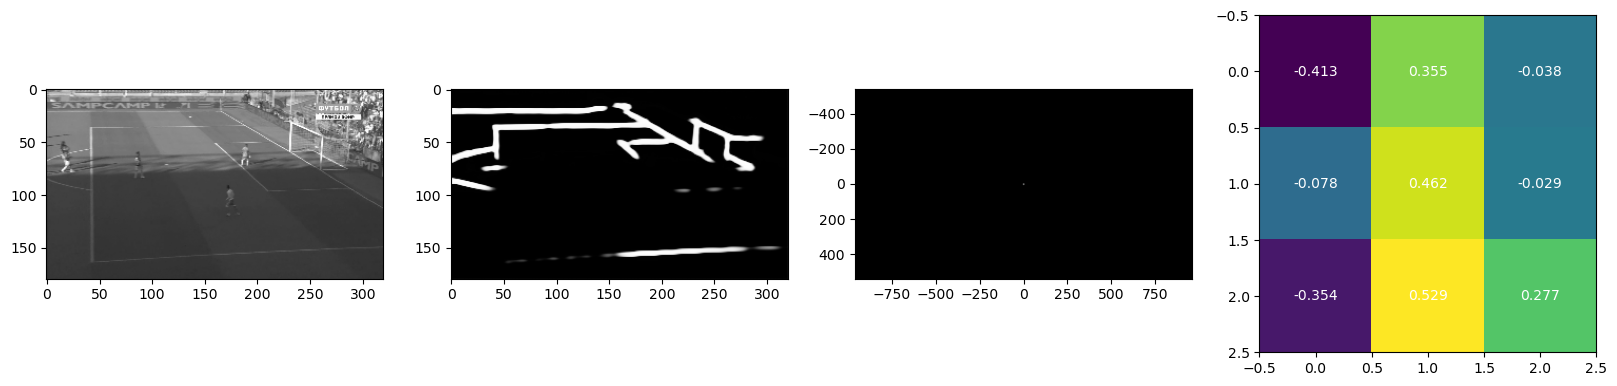

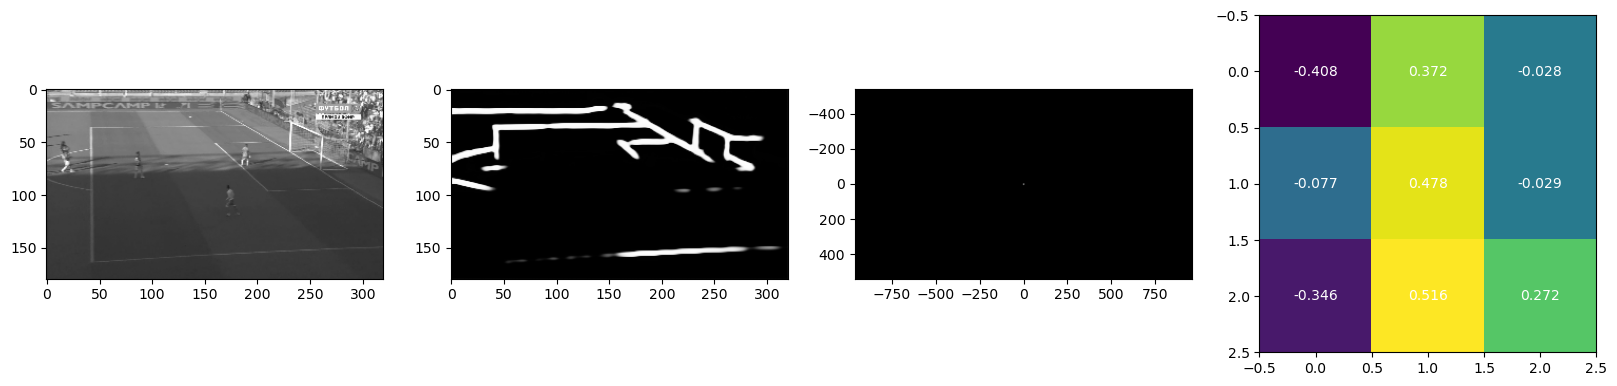

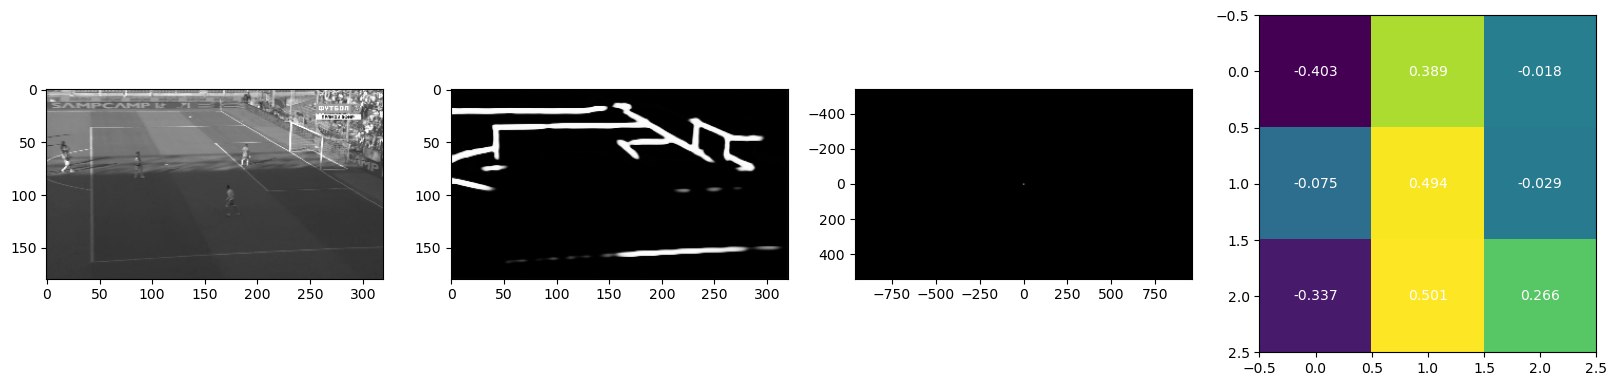

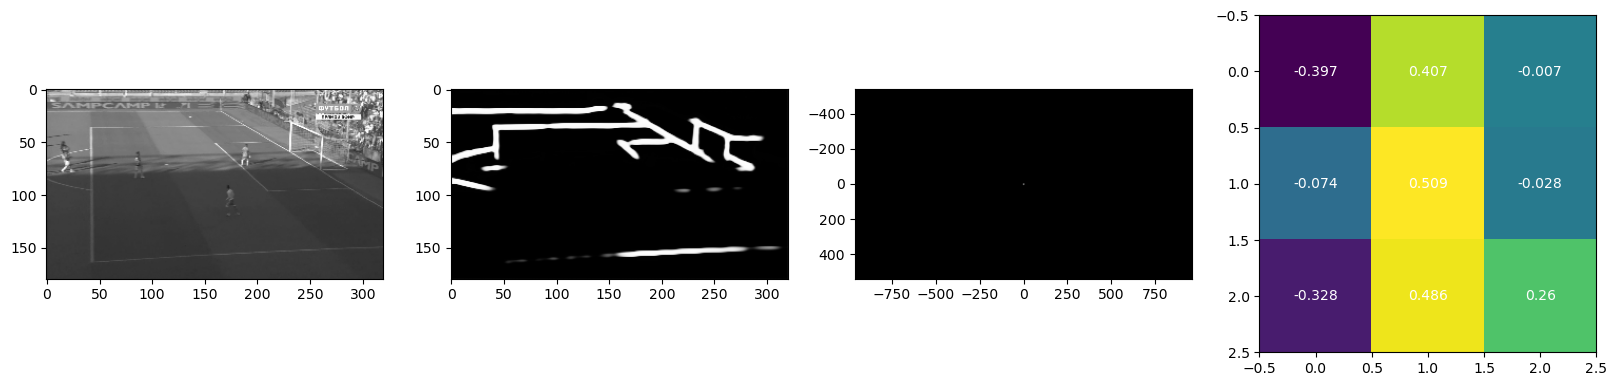

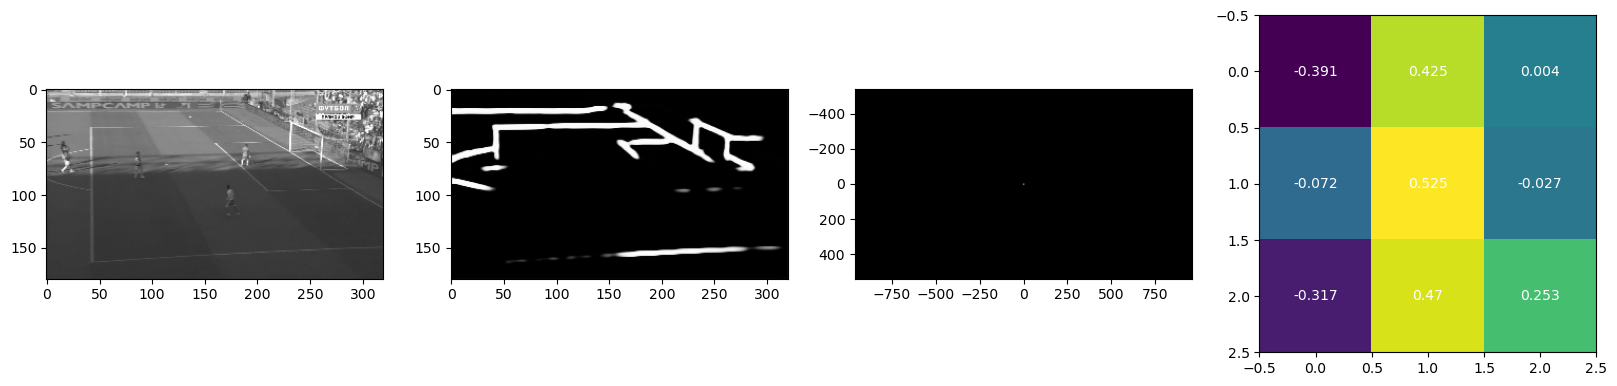

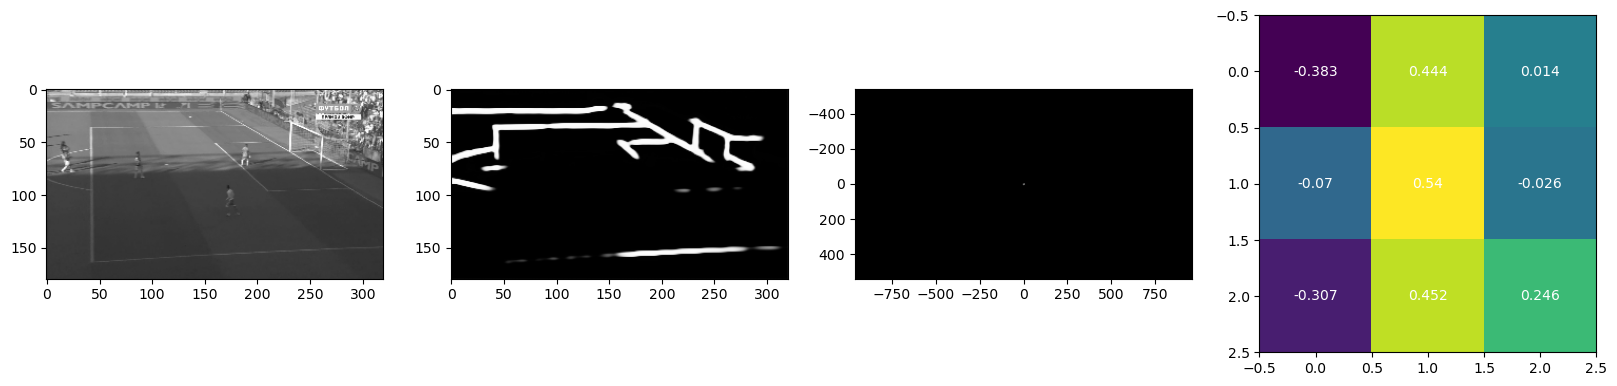

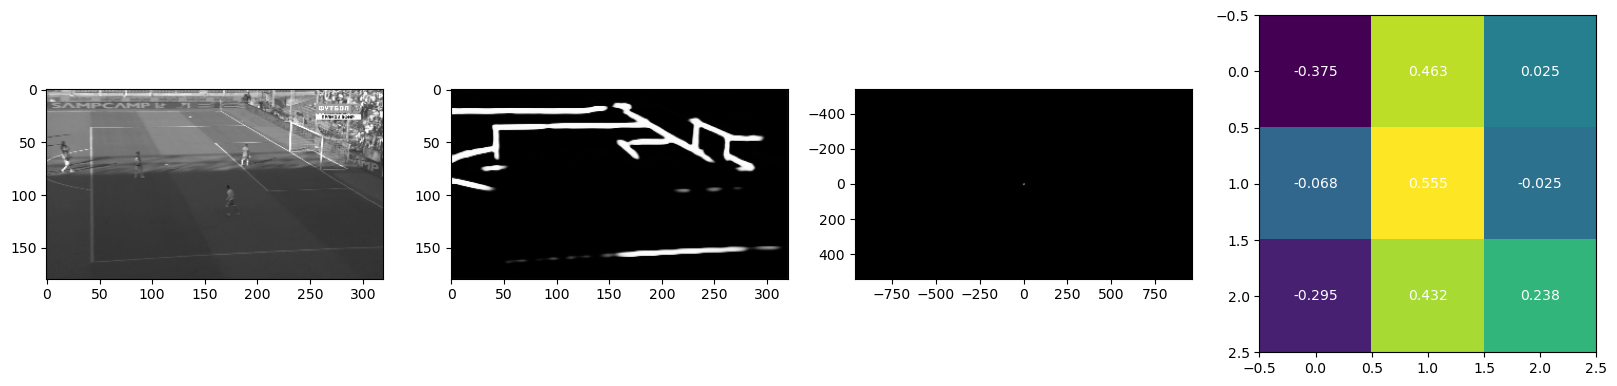

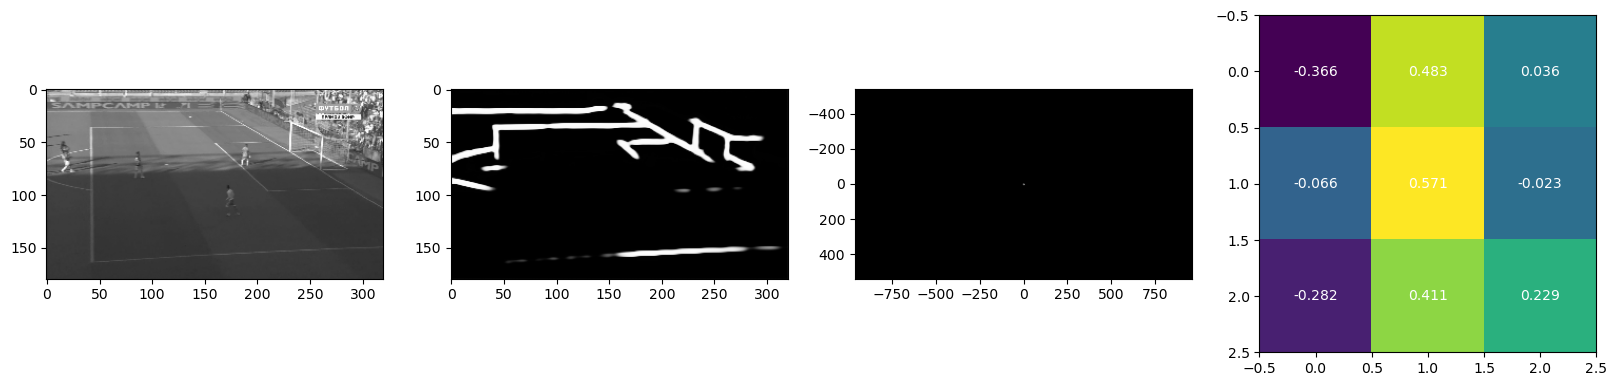

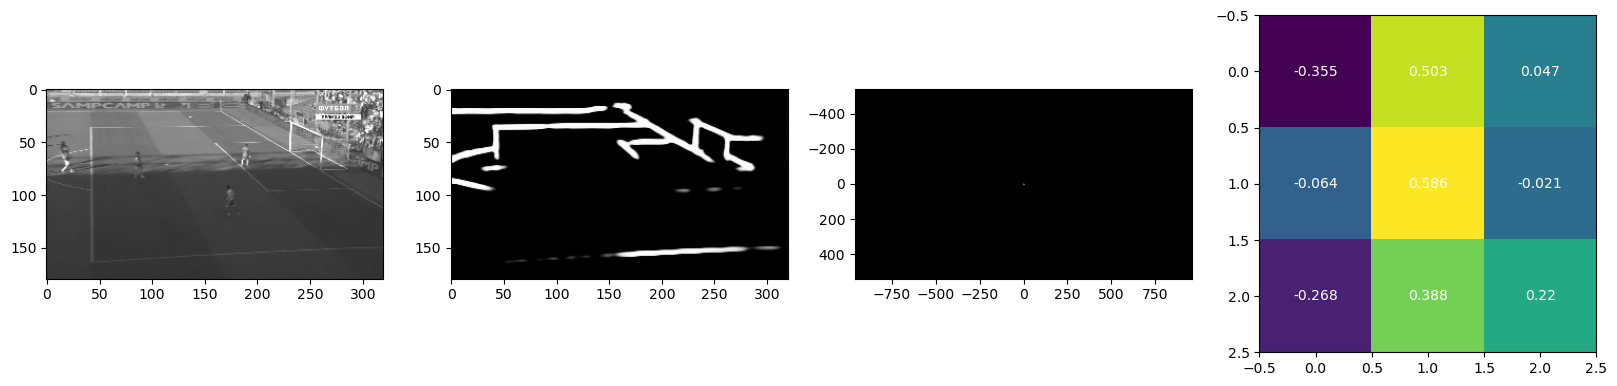

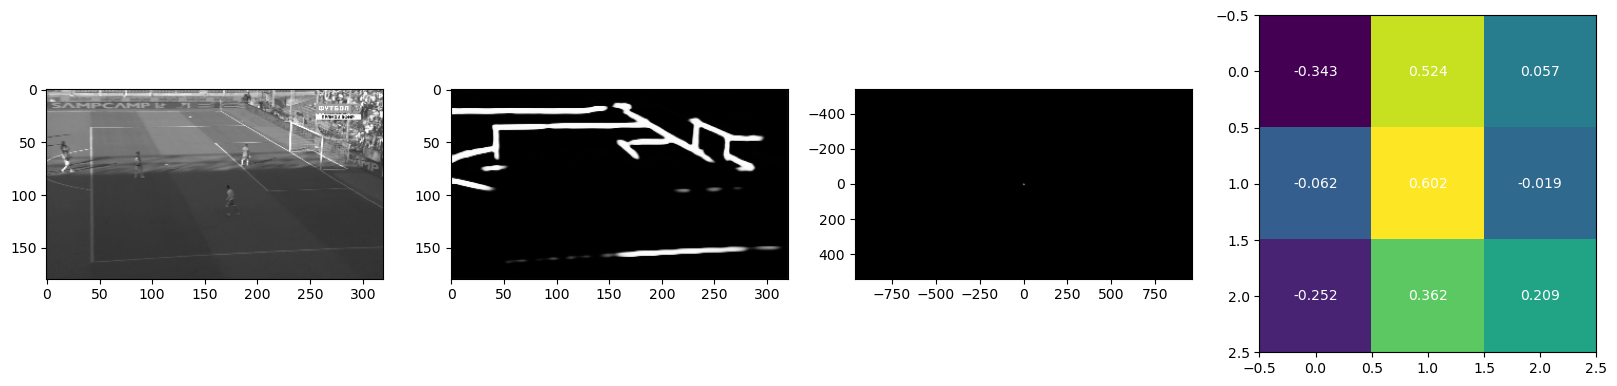

In [120]:
for epoch in range(n_epochs):                                       
    homography_model.train()                                            # Set the model to training mode
    train_loss = 0
    for batch_idx, (img, keypoints) in tqdm(enumerate(train_dataloader)):    # Iterate over batches of data
        # img:  [(N) x 180 (H) x 320 (W)]
        # keypoints: [(N) x 27 (N_pts) x 3 (dims)]

        img = img.float().unsqueeze(1).to(DEVICE)
        keypoints = keypoints.float().to(DEVICE)

        optimiser.zero_grad()                                           # Clear gradients from the previous iteration
        img_mask = unet_model(img)
        homography = homography_model(img_mask, original_pitch_mask)    # Forward pass through the model

        loss = homography_loss_fn(homography, keypoints)  # Calculate the loss
        train_loss += loss.item() * len(img)                            # Accumulate test loss 
        loss.backward()                                                 # Compute gradients (backpropagation)
        optimiser.step()                                                # Update model parameters

    train_loss /= len(train_dataloader.dataset)
    train_losses.append(train_loss)

    print('\nEpoch: {}, Train Loss: {:.4f} \n'.format(epoch + 1, train_loss))

    homography_model.eval()                                                   # Set the model to evaluation mode 
    test_loss, test_loss_dist, test_loss_tss_diff = 0, 0, 0
    with torch.no_grad():                                               # Disable gradient calculations for efficiency
        for batch_idx, (img, keypoints) in tqdm(enumerate(valid_dataloader)): # Iterate over test data
            img = img.float().unsqueeze(1).to(DEVICE)
            keypoints = keypoints.float().to(DEVICE)

            optimiser.zero_grad()                                # Clear gradients from the previous iteration
            img_mask = unet_model(img)
            homography = homography_model(img_mask, original_pitch_mask)              # Forward pass through the model
            
            loss = homography_loss_fn(homography, keypoints)
            test_loss += loss.item() * len(img)                  # Accumulate test loss 

            if batch_idx == 0:
                fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))
                def img_convert(img):
                    return img.permute((1, 2, 0)).cpu().numpy()

                H = homography[2].detach().cpu()

                axes.flat[0].imshow(img_convert(img[2]), cmap='gray')
                axes.flat[1].imshow(img_convert(img_mask[2]), cmap='gray')
                pitch = Pitch().apply_homography(H)
                pitch.plot(axes.flat[2], scale=3, thickness=9, extra_space_scale=3)
                print((pitch.keypoints / pitch.keypoints[:, 2].view(-1, 1))[list(PitchKeypointMapping.BOX_FIELD)])

                axes.flat[3].imshow(H)
                for i in range(3):
                    for j in range(3):
                        axes.flat[3].text(j, i, round(H[i, j].item(), ndigits=3), ha='center', va='center', color='w')

                fig.show()

    test_loss /= len(valid_dataloader.dataset)                           # Calculate average test loss
    test_losses.append(test_loss)

    print('\nEpoch: {}, Test Loss: {:.4f}\n'.format(epoch + 1, test_loss))

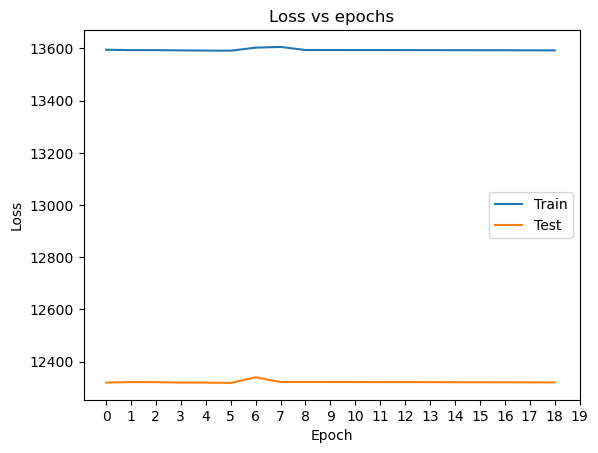

In [121]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.legend(labels=['Train', 'Test'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(test_losses) + 1, len(test_losses) // 16))
plt.title('Loss vs epochs')
plt.show()

## Field Localisation
Paper: https://openaccess.thecvf.com/content_cvpr_2017/papers/Homayounfar_Sports_Field_Localization_CVPR_2017_paper.pdf

Line: https://visionbook.mit.edu/3d_scene_understanding_single_view.html

<center>
    <img width="40%" src="media/field-parameterisation.png" />
    <img width="40%" src="media/horizon-line.png" />
</center>

### A projective model of the football pitch

In [122]:
def normalise_homogeneous(x):
    return x / x[2]

def plot_ray(ax, ray, T=1000):
    rray_1 = np.random.rand(3)
    rray_2 = np.random.rand(3)
    pt1 = normalise_homogeneous(np.cross(ray, rray_1))
    pt2 = normalise_homogeneous(np.cross(ray, rray_2))
    dp = pt2 - pt1
    pt1 -= T * dp
    pt2 += T * dp
    pt1 = normalise_homogeneous(pt1)
    pt2 = normalise_homogeneous(pt2)
    ax.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]])

In [123]:
def football_field(ax, ray_v1, ray_v2, ray_h1, ray_h2):
    src_v = normalise_homogeneous(np.cross(ray_v1, ray_v2))
    src_h = normalise_homogeneous(np.cross(ray_h1, ray_h2))
    plot_ray(ax, ray_v1)
    plot_ray(ax, ray_v2)
    print(ray_v1, ray_v2)

SRC_V, SRC_H = (450, -550, 1), (-450, 350, 1)
RAY_V0 = [(2, 3, 1)]

print(RAY_GRADs_V, RAY_GRADs_H)
print(RAYs_V, RAYs_H)

fig, ax = plt.subplots(1, 1)
football_field(ax, *RAYs_V, *RAYs_H)
plt.show()

NameError: name 'RAY_GRADs_V' is not defined